In [1]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path("../data/raw")

datasets = {
    "videos": [],
    "comments": [],
    "channels": [],
}

for csv_file in BASE_DIR.rglob("*.csv"):
    try:
        df = pd.read_csv(csv_file)

        df["source_file"] = csv_file.name
        df["source_path"] = str(csv_file)

        id_dir = next(
            (part for part in csv_file.parts if part.startswith("id_")),
            None
        )
        df["collection_id"] = id_dir

        stem_parts = csv_file.stem.split("_")
        country = stem_parts[-1] if len(stem_parts) > 2 else None
        df["country"] = country

        filename = csv_file.name.lower()

        if "video" in filename:
            datasets["videos"].append(df)

        elif "comment" in filename:
            datasets["comments"].append(df)

        elif "channel" in filename:
            datasets["channels"].append(df)

    except Exception as e:
        print(f"Erro ao ler {csv_file}: {e}")

videos_df = pd.concat(datasets["videos"], ignore_index=True) \
    if datasets["videos"] else pd.DataFrame()

comments_df = pd.concat(datasets["comments"], ignore_index=True) \
    if datasets["comments"] else pd.DataFrame()

channels_df = pd.concat(datasets["channels"], ignore_index=True) \
    if datasets["channels"] else pd.DataFrame()

print(f"Videos: {len(videos_df)}")
print(f"Comments: {len(comments_df)}")
print(f"Channels: {len(channels_df)}")


Videos: 3983
Comments: 226196
Channels: 3970


In [2]:
from IPython.display import display, Markdown
display(Markdown("## visão geral e estrutura do dataset"))
videos_df.info() 

display(Markdown("---"))

display(Markdown("## amostra dos dados (primeiras 5 linhas)"))
display(videos_df.head())

display(Markdown("---"))

display(Markdown("##  rsumo estatístico (variáveis nméricas)"))
display(videos_df.describe()) 

if videos_df.select_dtypes(include=['object']).shape[1] > 0:
    display(Markdown("## resumo estatístico (variáveis categóricas)"))
    display(videos_df.describe())

## visão geral e estrutura do dataset

<class 'pandas.DataFrame'>
RangeIndex: 3983 entries, 0 to 3982
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   video_id       3983 non-null   str    
 1   title          3983 non-null   str    
 2   channel_title  3983 non-null   str    
 3   channel_id     3983 non-null   str    
 4   published_at   3983 non-null   str    
 5   category_id    3983 non-null   int64  
 6   thumbnail      3983 non-null   str    
 7   view_count     3983 non-null   int64  
 8   like_count     3882 non-null   float64
 9   comment_count  3973 non-null   float64
 10  source_file    3983 non-null   str    
 11  source_path    3983 non-null   str    
 12  collection_id  3983 non-null   str    
 13  country        3983 non-null   str    
dtypes: float64(2), int64(2), str(10)
memory usage: 1.4 MB


---

## amostra dos dados (primeiras 5 linhas)

,video_id,title,channel_title,channel_id,published_at,category_id,thumbnail,view_count,like_count,comment_count,source_file,source_path,collection_id,country
0,4Uk8i9odiQs,How Apple is trying to stop phone snatching… #...,CarterPCs,UCi7wDE2ZTiR5QYYrUY5WhtA,2026-05-28T01:40:26Z,22,https://i.ytimg.com/vi/4Uk8i9odiQs/default.jpg,4120004,262475.0,4553.0,youtube_videos_us.csv,../data/raw/output_default_233731052026/id_28/...,id_28,us
1,izGBpPSoMoU,This 3D Printer Uses A Mosquito 😮,Zack D. Films,UCvz84_Q0BbvZThy75mbd-Dg,2026-05-23T19:30:04Z,19,https://i.ytimg.com/vi/izGBpPSoMoU/default.jpg,9168260,588698.0,4236.0,youtube_videos_us.csv,../data/raw/output_default_233731052026/id_28/...,id_28,us
2,bIBzLcCH4rA,When Data Centers Enter The Country,Snuff Cup,UCm-ra6k1zLgGw-uIVaM0vkA,2026-05-27T22:02:42Z,22,https://i.ytimg.com/vi/bIBzLcCH4rA/default.jpg,1258460,82436.0,4182.0,youtube_videos_us.csv,../data/raw/output_default_233731052026/id_28/...,id_28,us
3,co18MZypHm0,jbl go4 pvc pipe drop jumping,Dipesh Chauhan,UCY6gTaTARkQG6abRc7uU2oA,2026-05-26T02:56:05Z,22,https://i.ytimg.com/vi/co18MZypHm0/default.jpg,23111099,216395.0,131.0,youtube_videos_us.csv,../data/raw/output_default_233731052026/id_28/...,id_28,us
4,6V7TC0yjkM0,Wireless Charging Stopped Working!#wutheringwa...,wuwarchie,UC_g9H3mrDQeHlhNwLYMVDoA,2026-05-25T11:21:01Z,22,https://i.ytimg.com/vi/6V7TC0yjkM0/default.jpg,8060794,87261.0,243.0,youtube_videos_us.csv,../data/raw/output_default_233731052026/id_28/...,id_28,us


...

##  rsumo estatístico (variáveis nméricas)

,category_id,view_count,like_count,comment_count
count,3983.000000,3.983000e+03,3.882000e+03,3973.000000
mean,21.065026,2.350681e+06,8.416439e+04,1180.882205
std,5.030898,7.340565e+06,1.813868e+05,4634.421490
min,1.000000,3.529000e+03,1.210000e+02,0.000000
25%,20.000000,1.911665e+05,7.704750e+03,147.000000
50%,22.000000,7.650620e+05,2.818000e+04,409.000000
75%,24.000000,2.232216e+06,8.379400e+04,1054.000000
max,29.000000,1.565006e+08,2.635306e+06,154500.000000


/tmp/ipykernel_70582/685646150.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  if videos_df.select_dtypes(include=['object']).shape[1] > 0:


## resumo estatístico (variáveis categóricas)

,category_id,view_count,like_count,comment_count
count,3983.000000,3.983000e+03,3.882000e+03,3973.000000
mean,21.065026,2.350681e+06,8.416439e+04,1180.882205
std,5.030898,7.340565e+06,1.813868e+05,4634.421490
min,1.000000,3.529000e+03,1.210000e+02,0.000000
25%,20.000000,1.911665e+05,7.704750e+03,147.000000
50%,22.000000,7.650620e+05,2.818000e+04,409.000000
75%,24.000000,2.232216e+06,8.379400e+04,1054.000000
max,29.000000,1.565006e+08,2.635306e+06,154500.000000


In [3]:
null_pct = df.isnull().mean().sort_values(ascending=False)
null_abs = df.isnull().sum().sort_values(ascending=False)
null_df = pd.DataFrame({"nulos": null_abs, "pct_%": (null_pct*100).round(1)})
display(null_df.to_string())


'                     nulos  pct_%\nvideo_like_count       400    4.0\nauthor                   1    0.0\nvideo_id                 0    0.0\nchannel_title            0    0.0\ncollection_id            0    0.0\nsource_path              0    0.0\nsource_file              0    0.0\nvideo_comment_count      0    0.0\nvideo_view_count         0    0.0\nvideo_title              0    0.0\ncomment_thread_id        0    0.0\ntotal_reply_count        0    0.0\nupdated_at               0    0.0\npublished_at             0    0.0\nlike_count               0    0.0\ntext                     0    0.0\ncomment_id               0    0.0\ncountry                  0    0.0'

In [ ]:
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from datetime import datetime

In [ ]:
# display(Markdown("## LIMPEZA DE DADOS\n"))
 
# df_clean = videos_df.copy()

# df_clean = df_clean.replace(["", "None", "nan", "NaN", "unknown"], np.nan)

# cols_100_null = ["thumbnail", "channel_title"]
# df_clean.drop(columns=cols_100_null, inplace=True)
# display(Markdown(f"Removidas {len(cols_100_null)} colunas 100% nulas: {cols_100_null}"))

# df_clean = df_clean[df_clean['country'] != 'channel']

# dup_count = df_clean.duplicated(subset="video_id").sum()
# df_clean.drop_duplicates(subset="video_id", inplace=True)
# display(Markdown(f"Duplicatas removidas por video_id: {dup_count}"))
 
# df_clean["published_at"] = pd.to_datetime(df_clean["published_at"], errors="coerce")
# display(Markdown(f"published_at convertido para datetime"))
 
# LIKE_WEIGHT = 2
# COMMENT_WEIGHT = 5
# num_cols = ["view_count", "like_count", "comment_count", "official_category_id", "category_id"]
# for col in num_cols:
#     if col in df_clean.columns:
#         df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")
        
# df_clean["engagement_rate"] = np.where(
#     df_clean["view_count"] > 0,
#     (
#         df_clean["like_count"].fillna(0) * LIKE_WEIGHT +
#         df_clean["comment_count"].fillna(0) * COMMENT_WEIGHT
#     ) / df_clean["view_count"],
#     np.nan
# )
# df_clean["like_ratio"]    = df_clean["like_count"]    / df_clean["view_count"]
# df_clean["comment_ratio"] = df_clean["comment_count"] / df_clean["view_count"]
# display(Markdown(f"Criadas colunas: engagement_rate, like_ratio, comment_ratio"))
 
# df_clean["year"]  = df_clean["published_at"].dt.year
# df_clean["month"] = df_clean["published_at"].dt.month
# display(Markdown(f"Criadas colunas: year, month"))
 
# cap_views = df_clean["view_count"].quantile(0.995)
# outliers_n = (df_clean["view_count"] > cap_views).sum()
# df_clean["view_count_capped"] = df_clean["view_count"].clip(upper=cap_views)
# display(Markdown(f"view_count: {outliers_n} outliers capados no p99.5 ({cap_views:,.0f})"))
 
# # df_clean["source_label"] = df_clean["source_file"].str.replace(".csv","",regex=False)
# # display(Markdown(f"source_label criado"))
# display(Markdown(f"\nshape final: {df_clean.shape[0]} linhas x {df_clean.shape[1]} colunas"))

# POS_BASE_DIR = Path("../data/processed")
# POS_BASE_DIR.mkdir(parents=True, exist_ok=True)

# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# file_name = f"processed_videos_{timestamp}.csv"
# caminho_final = POS_BASE_DIR / file_name

# df_clean.to_csv(caminho_final, index=False, sep=',', encoding='utf-8')

# display(Markdown(f"\nsalvo no caminho: {caminho_final}"))



## LIMPEZA DE DADOS


Removidas 2 colunas 100% nulas: ['thumbnail', 'channel_title']

Duplicatas removidas por video_id: 1911

published_at convertido para datetime

Criadas colunas: engagement_rate, like_ratio, comment_ratio

Criadas colunas: year, month

view_count: 11 outliers capados no p99.5 (21,483,035)


shape final: 2072 linhas x 18 colunas


salvo no caminho: ../data/processed/processed_videos_20260601_120051.csv

In [ ]:
df_clean = videos_df.copy()

df_clean = df_clean.replace(["", "None", "nan", "NaN", "unknown"], np.nan)

df_clean = df_clean[df_clean["country"] != "channel"]
df_clean = df_clean.drop_duplicates(subset="video_id")

df_clean = df_clean.drop(columns=["thumbnail", "channel_title"], errors="ignore")

df_clean["published_at"] = pd.to_datetime(df_clean["published_at"], errors="coerce")

num_cols = ["view_count", "like_count", "comment_count", "official_category_id", "category_id"]
for col in num_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

LIKE_WEIGHT = 2
COMMENT_WEIGHT = 5

valid_views = df_clean["view_count"].gt(0)

df_clean["engagement_rate"] = np.where(
    valid_views,
    (
        df_clean["like_count"].fillna(0) * LIKE_WEIGHT +
        df_clean["comment_count"].fillna(0) * COMMENT_WEIGHT
    ) / df_clean["view_count"],
    np.nan
)

df_clean["like_ratio"] = np.where(
    valid_views,
    df_clean["like_count"].fillna(0) / df_clean["view_count"],
    np.nan
)

df_clean["comment_ratio"] = np.where(
    valid_views,
    df_clean["comment_count"].fillna(0) / df_clean["view_count"],
    np.nan
)

df_clean["year"] = df_clean["published_at"].dt.year
df_clean["month"] = df_clean["published_at"].dt.month

cap_views = df_clean["view_count"].quantile(0.995)
df_clean["view_count_capped"] = df_clean["view_count"].clip(upper=cap_views)


imputer = SimpleImputer(strategy="median")

df_clean[["view_count", "like_count", "comment_count"]] = (
    imputer.fit_transform(
        df_clean[["view_count", "like_count", "comment_count"]]
    )
)


shape final: 2072 linhas x 18 colunas


salvo no caminho: ../data/processed/processed_videos_20260601_120528.csv

In [ ]:
display(Markdown(f"\nshape final: {df_clean.shape[0]} linhas x {df_clean.shape[1]} colunas"))

POS_BASE_DIR = Path("../data/processed")
POS_BASE_DIR.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
file_name = f"processed_videos_{timestamp}.csv"
caminho_final = POS_BASE_DIR / file_name

df_clean.to_csv(caminho_final, index=False, sep=',', encoding='utf-8')

display(Markdown(f"\nsalvo no caminho: {caminho_final}"))

In [11]:
display(Markdown("## visão geral e estrutura do dataset"))
df_clean.info() 

display(Markdown("---"))

display(Markdown("## amostra dos dados (primeiras 5 linhas)"))
display(df_clean.head())

display(Markdown("---"))

display(Markdown("##  rsumo estatístico (variáveis nméricas)"))
display(df_clean.describe()) 

if df_clean.select_dtypes(include=['object']).shape[1] > 0:
    display(Markdown("## resumo estatístico (variáveis categóricas)"))
    display(df_clean.describe())

display(Markdown("##  colunas e etc"))
display(df_clean.columns)

## visão geral e estrutura do dataset

<class 'pandas.DataFrame'>
Index: 2072 entries, 0 to 3982
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   video_id           2072 non-null   str                
 1   title              2072 non-null   str                
 2   channel_id         2072 non-null   str                
 3   published_at       2072 non-null   datetime64[us, UTC]
 4   category_id        2072 non-null   int64              
 5   view_count         2072 non-null   int64              
 6   like_count         2017 non-null   float64            
 7   comment_count      2067 non-null   float64            
 8   source_file        2072 non-null   str                
 9   source_path        2072 non-null   str                
 10  collection_id      2072 non-null   str                
 11  country            2072 non-null   str                
 12  engagement_rate    2072 non-null   float64            
 13  like

---

## amostra dos dados (primeiras 5 linhas)

,video_id,title,channel_id,published_at,category_id,view_count,like_count,comment_count,source_file,source_path,collection_id,country,engagement_rate,like_ratio,comment_ratio,year,month,view_count_capped
0,4Uk8i9odiQs,How Apple is trying to stop phone snatching… #...,UCi7wDE2ZTiR5QYYrUY5WhtA,2026-05-28 01:40:26+00:00,22,4120004,262475.0,4553.0,youtube_videos_us.csv,../data/raw/output_default_233731052026/id_28/...,id_28,us,0.132940,0.063707,0.001105,2026,5,4.120004e+06
1,izGBpPSoMoU,This 3D Printer Uses A Mosquito 😮,UCvz84_Q0BbvZThy75mbd-Dg,2026-05-23 19:30:04+00:00,19,9168260,588698.0,4236.0,youtube_videos_us.csv,../data/raw/output_default_233731052026/id_28/...,id_28,us,0.130731,0.064210,0.000462,2026,5,9.168260e+06
2,bIBzLcCH4rA,When Data Centers Enter The Country,UCm-ra6k1zLgGw-uIVaM0vkA,2026-05-27 22:02:42+00:00,22,1258460,82436.0,4182.0,youtube_videos_us.csv,../data/raw/output_default_233731052026/id_28/...,id_28,us,0.147626,0.065505,0.003323,2026,5,1.258460e+06
3,co18MZypHm0,jbl go4 pvc pipe drop jumping,UCY6gTaTARkQG6abRc7uU2oA,2026-05-26 02:56:05+00:00,22,23111099,216395.0,131.0,youtube_videos_us.csv,../data/raw/output_default_233731052026/id_28/...,id_28,us,0.018755,0.009363,0.000006,2026,5,2.148303e+07
4,6V7TC0yjkM0,Wireless Charging Stopped Working!#wutheringwa...,UC_g9H3mrDQeHlhNwLYMVDoA,2026-05-25 11:21:01+00:00,22,8060794,87261.0,243.0,youtube_videos_us.csv,../data/raw/output_default_233731052026/id_28/...,id_28,us,0.021801,0.010825,0.000030,2026,5,8.060794e+06


...

/tmp/ipykernel_70582/3657080362.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  if df_clean.select_dtypes(include=['object']).shape[1] > 0:


## resumo estatístico (variáveis categóricas)

,category_id,view_count,like_count,comment_count,engagement_rate,like_ratio,comment_ratio,year,month,view_count_capped
count,2072.000000,2.072000e+03,2.017000e+03,2067.000000,2072.000000,2072.000000,2072.000000,2072.0,2072.000000,2.072000e+03
mean,20.923745,1.781682e+06,6.860663e+04,1010.594098,0.108486,0.049467,0.001910,2026.0,5.011100,1.668525e+06
std,5.080423,4.786992e+06,1.399956e+05,4564.298408,0.089877,0.040504,0.003584,0.0,0.125742,2.945497e+06
min,1.000000,3.529000e+03,1.210000e+02,0.000000,0.000000,0.000000,0.000000,2026.0,4.000000,3.529000e+03
25%,20.000000,1.681938e+05,6.843000e+03,121.500000,0.053916,0.024970,0.000144,2026.0,5.000000,1.681938e+05
50%,22.000000,6.545600e+05,2.404600e+04,329.000000,0.089782,0.041761,0.000558,2026.0,5.000000,6.545600e+05
75%,24.000000,1.806919e+06,6.973000e+04,876.000000,0.140923,0.064599,0.002176,2026.0,5.000000,1.806919e+06
max,29.000000,1.558163e+08,2.625207e+06,154500.000000,1.804477,0.859734,0.048254,2026.0,6.000000,2.148303e+07


##  colunas e etc

Index(['video_id', 'title', 'channel_id', 'published_at', 'category_id',
       'view_count', 'like_count', 'comment_count', 'source_file',
       'source_path', 'collection_id', 'country', 'engagement_rate',
       'like_ratio', 'comment_ratio', 'year', 'month', 'view_count_capped'],
      dtype='str')

In [ ]:
from __future__ import annotations
 
import sys
from datetime import datetime, timezone
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

ROOT: Path = Path.cwd().parent
sys.path.append(str(ROOT))

from src.core.plot_eda import YouTubeDashboard

In [ ]:
dashboard = YouTubeDashboard(df_clean)
figures = dashboard.generate_separate_plots(output_dir="meus_plots")
# plt.show()
# plt.close(fig)


                 view_count  like_count  comment_count  engagement_rate
view_count         1.000000    0.810108       0.179542        -0.118523
like_count         0.810108    1.000000       0.330598         0.016862
comment_count      0.179542    0.330598       1.000000         0.062513
engagement_rate   -0.118523    0.016862       0.062513         1.000000


2026-06-01 11:24:41,582 - INFO - Plot salvo: meus_plots/01_mapa_nulidade.png
2026-06-01 11:24:41,902 - INFO - Plot salvo: meus_plots/02_distribuicao_views.png
2026-06-01 11:24:42,057 - INFO - Plot salvo: meus_plots/03_top_paises.png


country
us    919
br    534
ar    465
Name: count, dtype: int64


2026-06-01 11:24:42,255 - INFO - Plot salvo: meus_plots/04_macro_categoria.png
2026-06-01 11:24:42,444 - INFO - Plot salvo: meus_plots/05_engajamento_por_fonte.png
2026-06-01 11:24:42,654 - INFO - Plot salvo: meus_plots/06_publicacoes_mes.png
2026-06-01 11:24:42,879 - INFO - Plot salvo: meus_plots/07_boxplot_views_categoria.png
2026-06-01 11:24:43,210 - INFO - Plot salvo: meus_plots/08_correlacao.png
2026-06-01 11:24:43,538 - INFO - Plot salvo: meus_plots/09_scatter_views_likes.png
2026-06-01 11:24:43,695 - INFO - Plot salvo: meus_plots/10_sumario_limpeza.png


In [ ]:
# df_clean.loc[df_clean['country'] == 'channel', 'country']

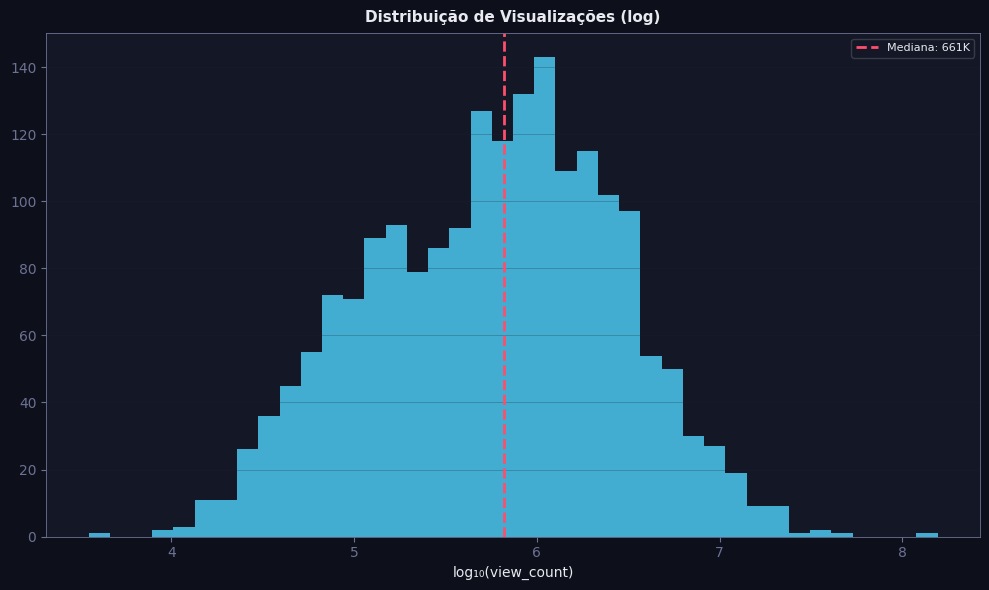

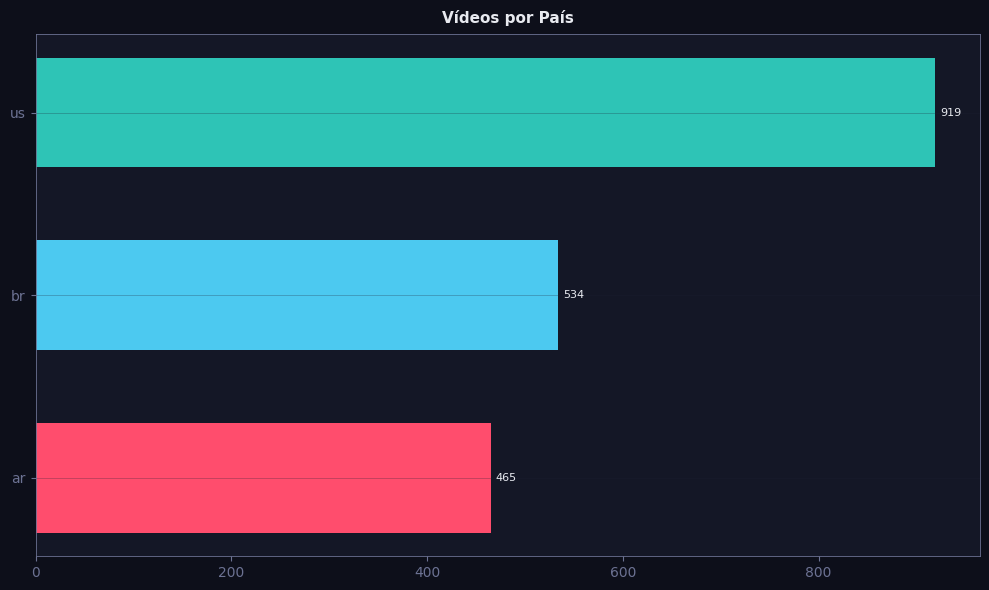

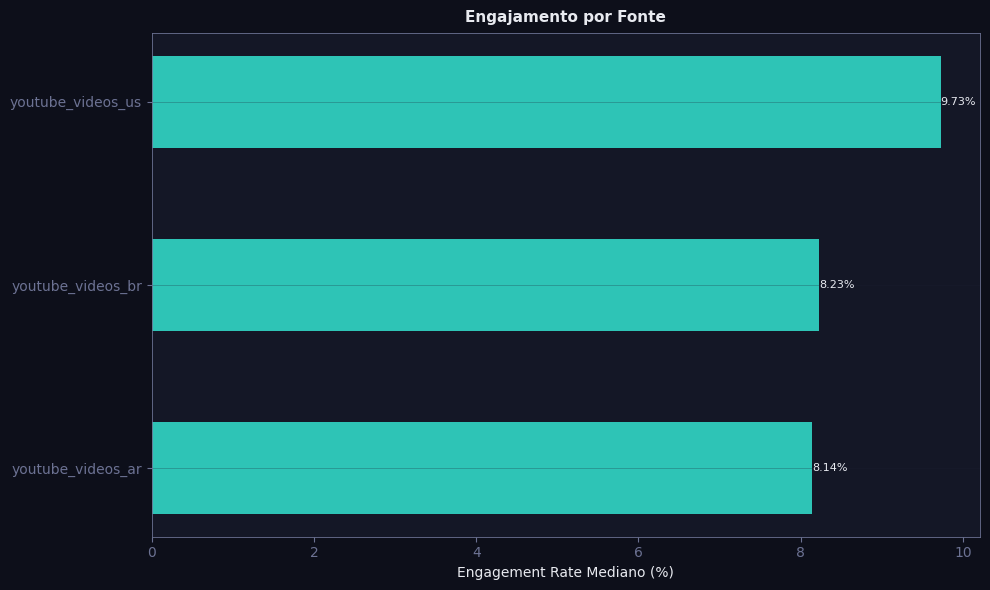

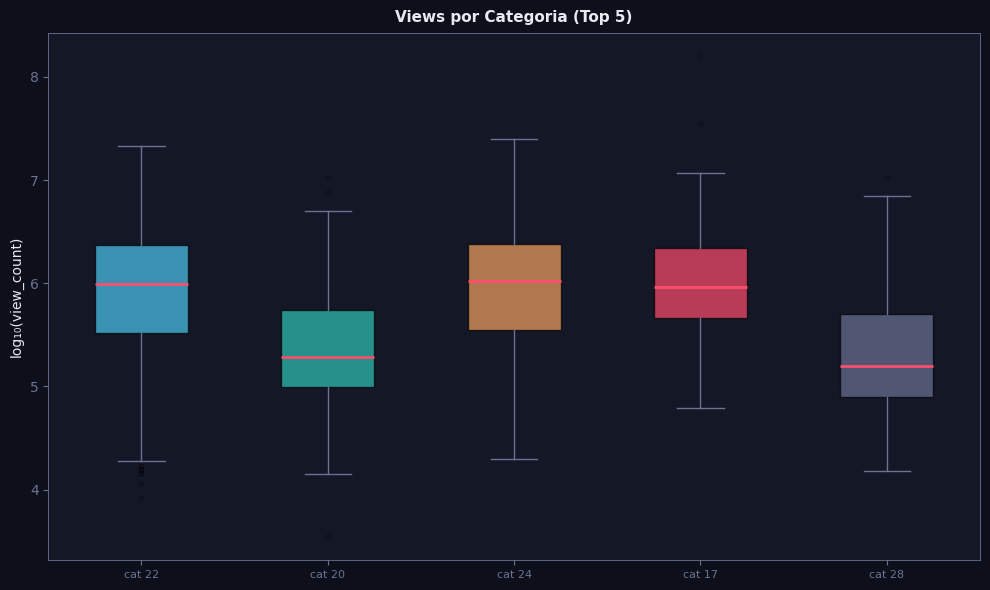

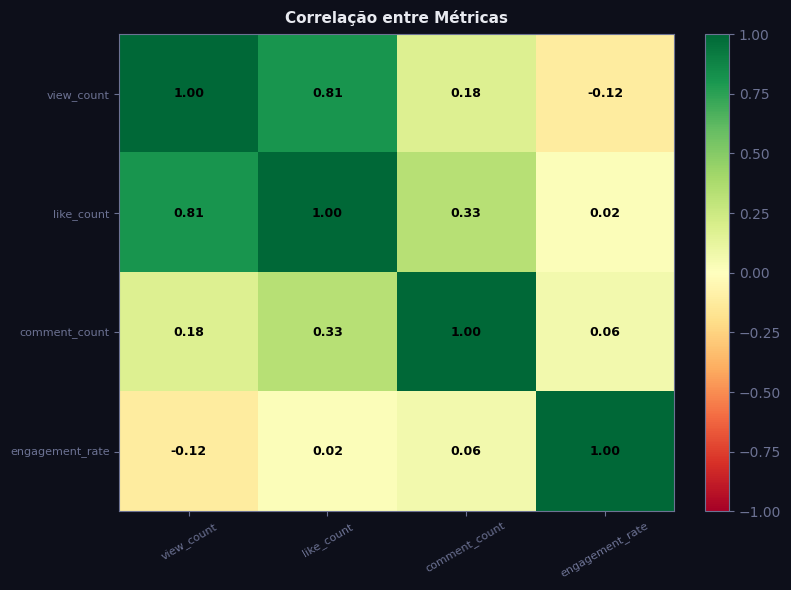

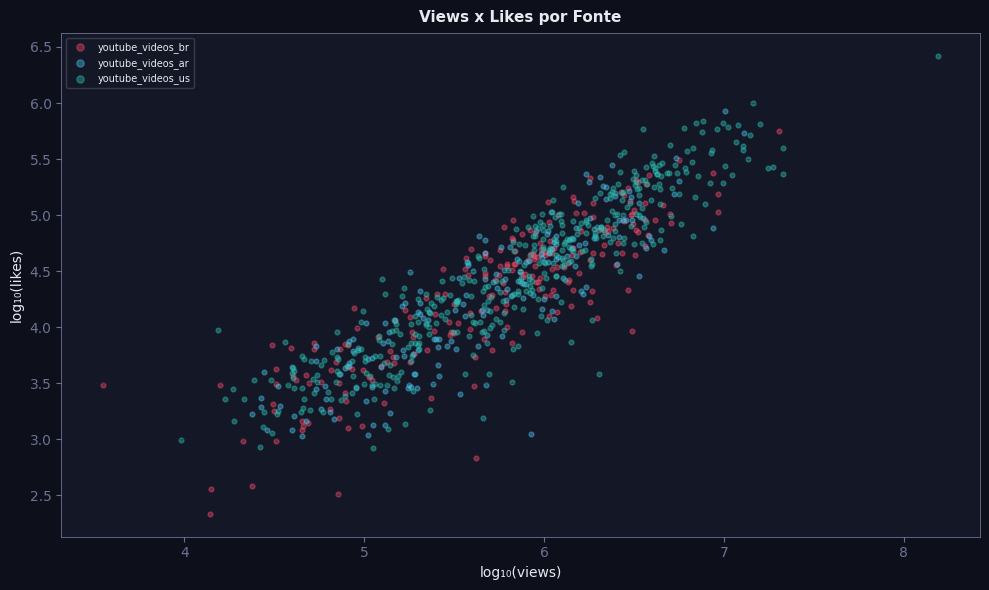

In [ ]:
display(figures[1])
display(figures[2])
display(figures[4])
display(figures[6])
display(figures[7])
display(figures[8])